In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from spacecraft_cmg import (
    SpacecraftCMG,
    AttitudeController,
    GSRISteering,
    MomentumRecoverySteering,
    MPPISteering,        # placeholder — swap in when ready
)

In [2]:
# ================================================================
#  Spacecraft + CMG system  (Table 2 defaults)
# ================================================================
DT = 0.1    # time step [s]

sc   = SpacecraftCMG(dt=DT)
ctrl = AttitudeController(J=sc.J, dt=DT)

# Available steering laws — swap freely in the simulation loop
gsri_law = GSRISteering(k_sr=0.01)
mr_law   = MomentumRecoverySteering(eta=0.1)
# mppi_law = MPPISteering(...)   # TODO

In [3]:
# ================================================================
#  Simulation parameters
# ================================================================
T_MAX = 30.0                          # total maneuver time [s]
STEPS = int(T_MAX / DT)
TIME  = np.linspace(0.0, T_MAX - DT, STEPS)

# Desired attitude: 70-degree yaw (Fig. 5-8 in Oghim et al. 2025)
yaw_cmd_deg = 70.0
half = np.deg2rad(yaw_cmd_deg) / 2
Q_D  = np.array([np.cos(half), 0.0, 0.0, np.sin(half)])

In [4]:
# ================================================================
#  Run: Conventional approach (CNV)
#
#  AttitudeController (Eq. 25) → GSRISteering (Eq. 27) throughout.
#  No DRL phase — this is the baseline the paper compares against.
#
#  To switch to MPPI later, replace gsri_law with mppi_law below.
# ================================================================
sc.reset()
ctrl.reset()

log_qe    = np.zeros((STEPS, 4))   # attitude error quaternion [qwe, qvex, qvey, qvez]
log_omega = np.zeros((STEPS, 3))   # angular rates [deg/s]
log_ddot  = np.zeros((STEPS, 4))   # applied (clipped) gimbal rates [rad/s]
log_sm    = np.zeros(STEPS)        # singularity measure m = det((A/h)(A/h)^T)

for i, t in enumerate(TIME):
    qe, qve = sc.attitude_error(Q_D)

    tau_sc    = ctrl.compute_torque(qe, sc.omega)   # desired spacecraft torque [N·m]
    delta_dot = gsri_law.compute(sc, tau_sc, t)     # commanded gimbal rates [rad/s]

    state = sc.step(delta_dot)                       # RK4 integration (clips δ̇ internally)

    log_qe[i]    = qe
    log_omega[i] = np.rad2deg(state["omega"])
    log_ddot[i]  = np.clip(delta_dot, -sc.delta_dot_max, sc.delta_dot_max)  # applied
    log_sm[i]    = state["singularity_measure"]

print(f"Final qe (target [1,0,0,0]): {log_qe[-1].round(4)}")
print(f"SM min / max: {log_sm.min():.4f} / {log_sm.max():.4f}")

Final qe (target [1,0,0,0]): [ 1.      0.     -0.      0.0069]
SM min / max: 0.0001 / 1.3165


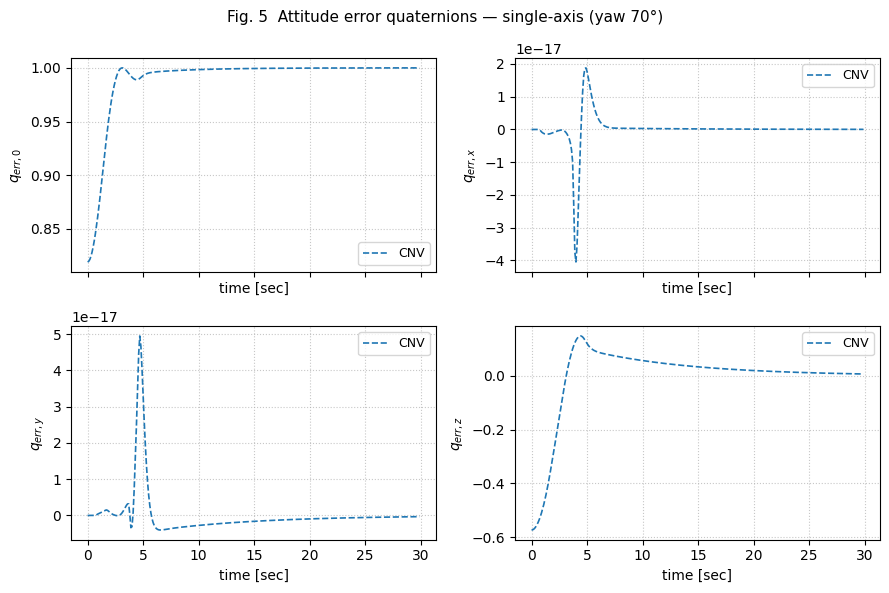

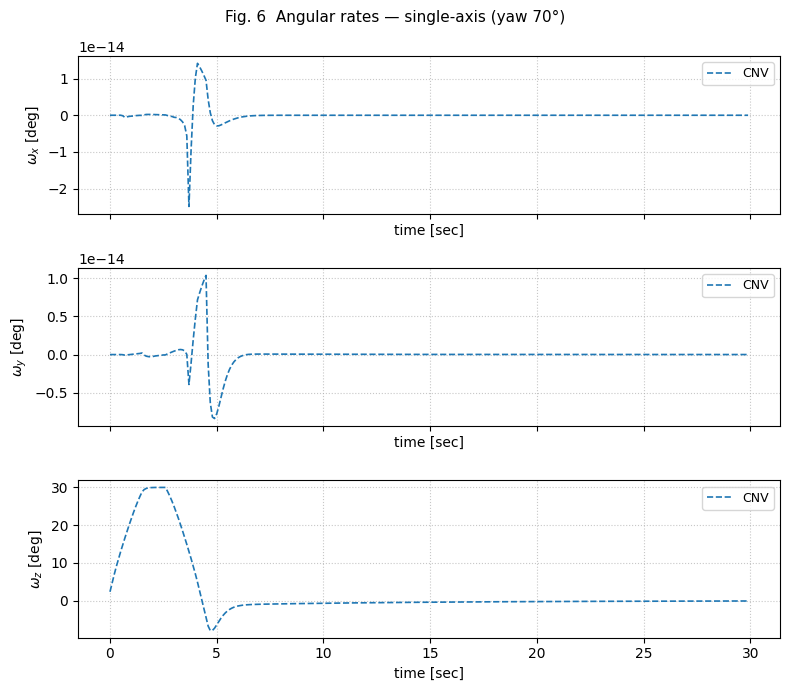

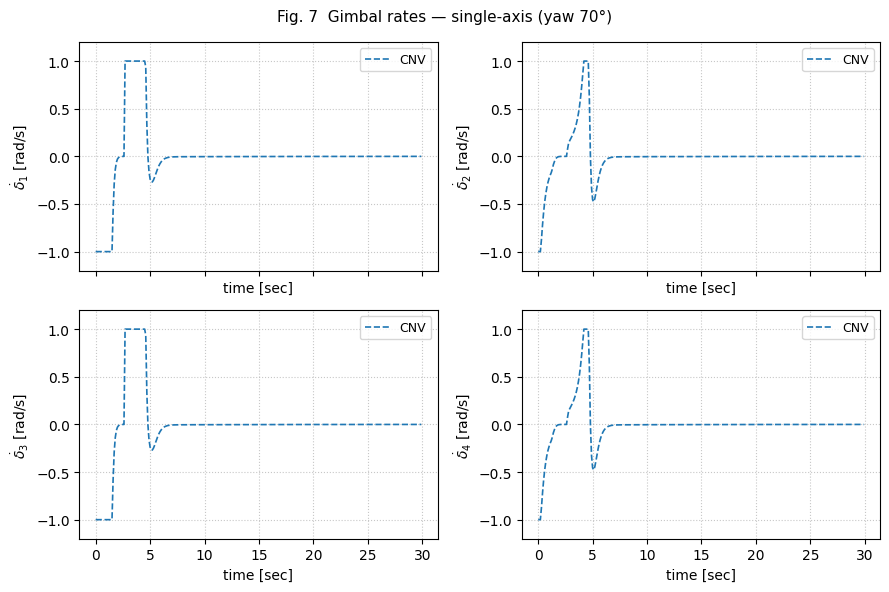

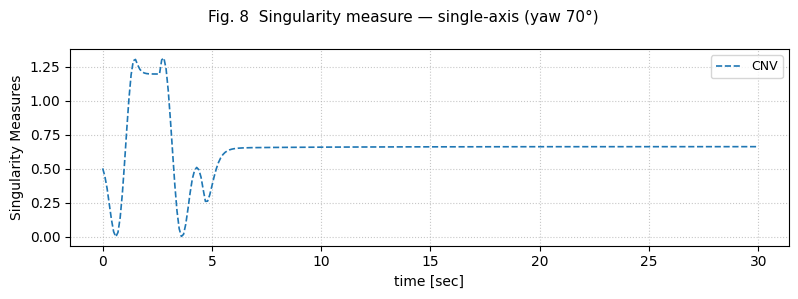

In [5]:
# ================================================================
#  Figures 5 – 8  (CNV, single-axis yaw 70°)
# ================================================================

CNV = dict(color='#1f77b4', linestyle='--', linewidth=1.2, label='CNV')

def fmt(ax, ylabel, xlabel='time [sec]'):
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.7)

# ---- Fig 5: Attitude error quaternions ----
fig5, axes = plt.subplots(2, 2, figsize=(9, 6), sharex=True)
fig5.suptitle('Fig. 5  Attitude error quaternions — single-axis (yaw 70°)', fontsize=11)
for ax, idx, lbl in zip(axes.flatten(), range(4),
                        [r'$q_{err,0}$', r'$q_{err,x}$', r'$q_{err,y}$', r'$q_{err,z}$']):
    ax.plot(TIME, log_qe[:, idx], **CNV)
    fmt(ax, lbl)
fig5.tight_layout()
plt.show()

# ---- Fig 6: Angular rates ----
fig6, axes = plt.subplots(3, 1, figsize=(8, 7), sharex=True)
fig6.suptitle('Fig. 6  Angular rates — single-axis (yaw 70°)', fontsize=11)
for ax, idx, lbl in zip(axes, range(3),
                        [r'$\omega_x$ [deg]', r'$\omega_y$ [deg]', r'$\omega_z$ [deg]']):
    ax.plot(TIME, log_omega[:, idx], **CNV)
    fmt(ax, lbl)
fig6.tight_layout()
plt.show()

# ---- Fig 7: Gimbal rates ----
fig7, axes = plt.subplots(2, 2, figsize=(9, 6), sharex=True)
fig7.suptitle('Fig. 7  Gimbal rates — single-axis (yaw 70°)', fontsize=11)
for ax, idx, lbl in zip(axes.flatten(), range(4),
                        [r'$\dot{\delta}_1$ [rad/s]', r'$\dot{\delta}_2$ [rad/s]',
                         r'$\dot{\delta}_3$ [rad/s]', r'$\dot{\delta}_4$ [rad/s]']):
    ax.plot(TIME, log_ddot[:, idx], **CNV)
    ax.set_ylim(-1.2, 1.2)
    fmt(ax, lbl)
fig7.tight_layout()
plt.show()

# ---- Fig 8: Singularity measure ----
fig8, ax8 = plt.subplots(figsize=(8, 3))
fig8.suptitle('Fig. 8  Singularity measure — single-axis (yaw 70°)', fontsize=11)
ax8.plot(TIME, log_sm, **CNV)
fmt(ax8, 'Singularity Measures')
fig8.tight_layout()
plt.show()